In [3]:
import os
import numpy as np
import cupy as cp
import numba as nb
from numba import cuda
import scipy
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


In [4]:
workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [5]:
def fit_gmm_components(intensity_image, n_components=3, n_bins=256):
    """
    Fit Gaussian Mixture Model to SAR intensity image.
    
    The 3 components typically represent:
    - C1: Clutter (low intensity)
    - C2: Speckle noise (medium intensity)  
    - T: Target scattering points (high intensity)
    
    Args:
        intensity_image: Log-mapped intensity image in range [0, 1]
        n_components: Number of Gaussian components (default 3)
        n_bins: Number of bins for histogram visualization (default 256)
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with GMM parameters and fitted model
    """
    # Flatten the intensity image for GMM fitting
    intensity_flat = intensity_image.flatten().reshape(-1, 1)
    
    # Fit GMM with 3 components
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',  # Full covariance matrices
        max_iter=100,
        # random_state=random_state,
        n_init=10  # Multiple initializations for stability
    )
    gmm.fit(intensity_flat)
    
    # Get parameters
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Sort by mean (ascending): C1 (clutter) < C2 (speckle) < T (target)
    sorted_idx = np.argsort(means)
    
    theta_C1 = {
        'mu': means[sorted_idx[0]], 
        'sigma': stds[sorted_idx[0]], 
        'pi': weights[sorted_idx[0]],
        'label': 'C1'
    }
    theta_C2 = {
        'mu': means[sorted_idx[1]], 
        'sigma': stds[sorted_idx[1]], 
        'pi': weights[sorted_idx[1]],
        'label': 'C2'
    }
    theta_T = {
        'mu': means[sorted_idx[2]], 
        'sigma': stds[sorted_idx[2]], 
        'pi': weights[sorted_idx[2]],
        'label': 'Target'
    }
    
    # Compute histogram for visualization
    histogram, bin_edges = np.histogram(intensity_flat, bins=n_bins, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return {
        'gmm': gmm,
        'components': [theta_C1, theta_C2, theta_T],
        'histogram': (histogram, bin_centers),
        'sorted_idx': sorted_idx
    }


def visualize_gmm_fit(intensity_image, gmm_result):
    """
    Visualize the GMM fit on intensity histogram (Figure 6c style).
    
    Matches the SSR paper's visualization with:
    - Y-axis: Number of Pixels (not density)
    - Gaussian curves scaled to match histogram counts
    """
    components = gmm_result['components']
    gmm = gmm_result['gmm']
    
    # Create histogram with COUNTS (not density)
    intensity_flat = intensity_image.flatten()
    counts, bin_edges = np.histogram(intensity_flat, bins=256, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_centers[1] - bin_centers[0]
    
    plt.figure(figsize=(12, 6))
    
    # Plot histogram as bar chart
    plt.bar(bin_centers, counts, width=bin_width, 
            alpha=0.5, label='Intensity Histogram', color='gray')
    
    # Plot individual Gaussian components
    x = np.linspace(0, 1, 500)
    colors = ['blue', 'red', 'green']  # C1=blue, C2=red, T=green (from paper)
    labels = ['Shadow (C1)', 'Clutter (C2)', 'Target (T)']
    
    total_pixels = len(intensity_flat)
    
    for comp, color, label in zip(components, colors, labels):
        # Gaussian PDF (without weight)
        gaussian_pdf = (1/(comp['sigma']*np.sqrt(2*np.pi))) * \
                       np.exp(-0.5*((x - comp['mu'])/comp['sigma'])**2)
        
        # Scale to pixel counts: weight × total_pixels × bin_width × PDF
        gaussian_counts = comp['pi'] * total_pixels * bin_width * gaussian_pdf
        
        plt.plot(x, gaussian_counts, color=color, linewidth=2.5,
                label=f"{label}: μ={comp['mu']:.3f}, σ={comp['sigma']:.3f}")
    
    # Plot total GMM (sum of all components)
    total_pdf = np.exp(gmm.score_samples(x.reshape(-1, 1)))
    total_counts = total_pixels * bin_width * total_pdf
    plt.plot(x, total_counts, 'k--', linewidth=2, label='GMM Total')
    
    plt.xlabel('Intensity')
    plt.ylabel('Number of Pixels')
    plt.title('GMM Fit: SAR Intensity Components')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
def extract_clutter_hard_segmentation(log_mapped_image, gmm_result):
    """
    Extract clutter pixels using hard segmentation (maximum likelihood).
    
    Args:
        log_mapped_image: Log-mapped intensity image [0, 1]
        gmm_result: Dictionary from fit_gmm_components()
    
    Returns:
        clutter_pixels: 1D array of clutter pixel intensities
        clutter_mask: 2D boolean mask (True = clutter, False = target)
    """
    gmm = gmm_result['gmm']
    sorted_idx = gmm_result['sorted_idx']
    
    # Flatten image
    intensities = log_mapped_image.flatten().reshape(-1, 1)
    
    # Predict component for each pixel (0, 1, or 2)
    labels = gmm.predict(intensities)
    
    # Target component has highest mean (sorted_idx[2])
    target_label = sorted_idx[2]
    
    # Create clutter mask (exclude target pixels)
    clutter_mask_flat = (labels != target_label)
    clutter_mask = clutter_mask_flat.reshape(log_mapped_image.shape)
    
    # Extract clutter pixel intensities
    clutter_pixels = intensities[clutter_mask_flat].flatten()
    
    return clutter_pixels, clutter_mask

def visualize_segmentation(log_mapped_image, gmm_result):
    """Visualize the hard segmentation result."""
    clutter_pixels, clutter_mask = extract_clutter_hard_segmentation(
        log_mapped_image, gmm_result
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(log_mapped_image, cmap='gray')
    axes[0].set_title('Original Log-Mapped Image')
    axes[0].axis('off')
    
    # Clutter mask
    axes[1].imshow(clutter_mask, cmap='RdYlGn')
    axes[1].set_title('Clutter Mask (Green=Clutter, Red=Target)')
    axes[1].axis('off')
    
    # Overlay
    overlay = np.zeros((*log_mapped_image.shape, 3))
    overlay[:, :, 0] = log_mapped_image  # R channel
    overlay[:, :, 1] = log_mapped_image  # G channel
    overlay[:, :, 2] = log_mapped_image  # B channel
    overlay[~clutter_mask, 0] = 1.0  # Highlight target in red
    
    axes[2].imshow(overlay)
    axes[2].set_title('Target Pixels Highlighted (Red)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print stats
    print(f"Total pixels: {log_mapped_image.size}")
    print(f"Clutter pixels: {clutter_mask.sum()} ({100*clutter_mask.sum()/log_mapped_image.size:.1f}%)")
    print(f"Target pixels: {(~clutter_mask).sum()} ({100*(~clutter_mask).sum()/log_mapped_image.size:.1f}%)")
    print(f"\nClutter mean: {clutter_pixels.mean():.4f}")
    print(f"Clutter std: {clutter_pixels.std():.4f}")

In [7]:
ds = sorted(
        os.listdir(
            os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1")
    ))[0]

In [8]:
image = np.load(os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth/2s1", ds))

In [9]:
gmm_result = fit_gmm_components(image, n_components=3, n_bins=256)

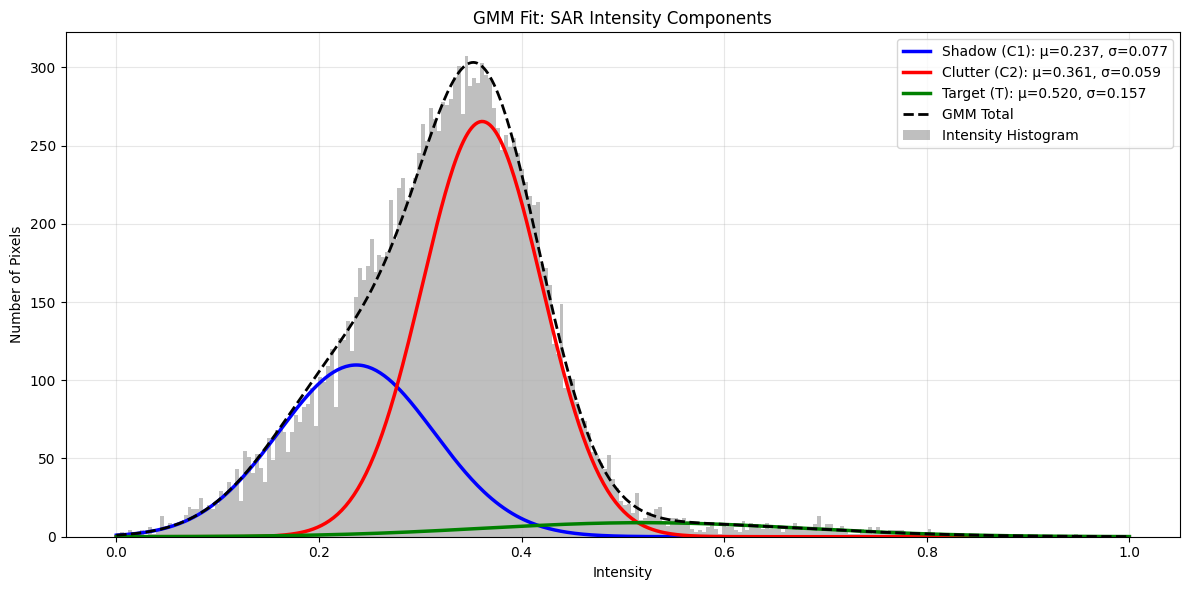

In [10]:
visualize_gmm_fit(image, gmm_result)

In [11]:
extract_clutter_hard_segmentation(image, gmm_result)

(array([0.18751204, 0.29051417, 0.34406334, ..., 0.21526787, 0.2257727 ,
        0.21792832], shape=(15891,), dtype=float32),
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(128, 128)))

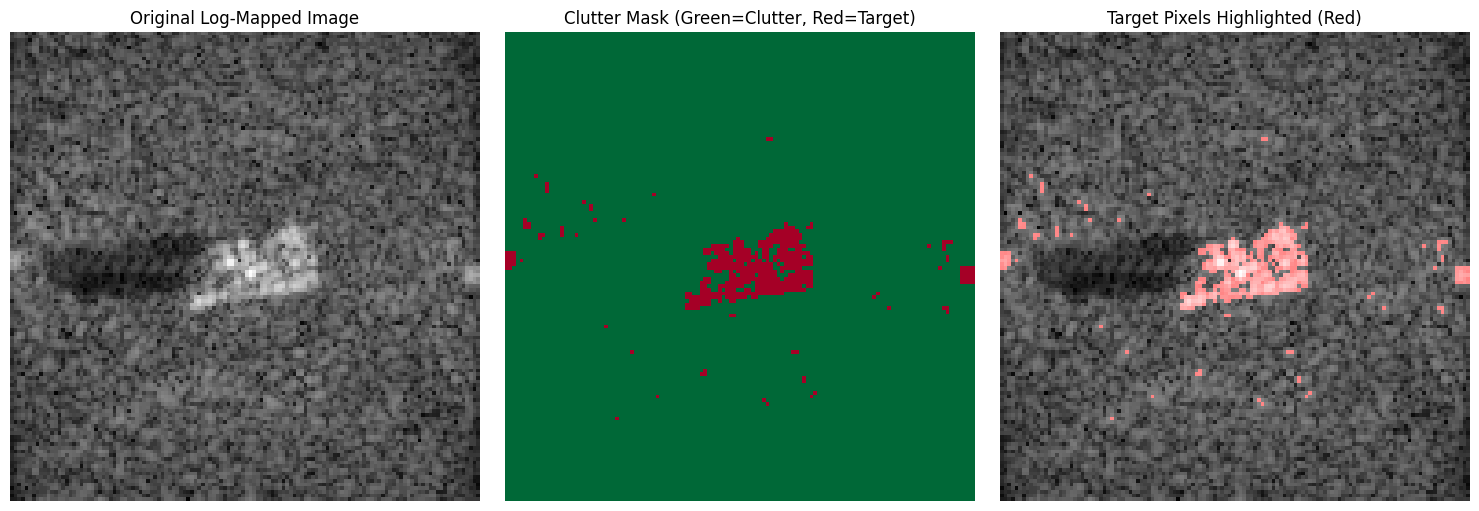

Total pixels: 16384
Clutter pixels: 15891 (97.0%)
Target pixels: 493 (3.0%)

Clutter mean: 0.3192
Clutter std: 0.0891


In [12]:
visualize_segmentation(image, gmm_result)